# **Stock Price Prediction Project using LSTM and RNN**

## **Install Packages**


In [120]:
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

### **Import Libraries**

In [121]:
from datetime import datetime
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras
import yfinance as yf
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler
from pandas_datareader.data import DataReader
from pandas_datareader import data as pdr
import pandas_ta as ta
from keras.layers import LSTM, SimpleRNN
from keras.models import Sequential
from keras.layers import Dense

In [122]:
keras.backend.set_image_data_format("channels_last")
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

## **Simple Neural Network in Tensorflow**

In [123]:
abalone_features = ["Length", "Diameter", "Height", "Whole weight", "Shucked weight", 
                    "Viscera weight", "Shell weight", "Age"]

In [124]:
abalone_train = pd.read_csv(
    "https://storage.googleapis.com/download.tensorflow.org/data/abalone_train.csv",
    names=abalone_features)

abalone_test = pd.read_csv(
    "https://storage.googleapis.com/download.tensorflow.org/data/abalone_test.csv",
    names=abalone_features)

In [125]:
abalone_train.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Age
0,0.435,0.335,0.110,0.334,0.1355,0.0775,0.0965,7
1,0.585,0.450,0.125,0.874,0.3545,0.2075,0.2250,6
2,0.655,0.510,0.160,1.092,0.3960,0.2825,0.3700,14
3,0.545,0.425,0.125,0.768,0.2940,0.1495,0.2600,16
4,0.545,0.420,0.130,0.879,0.3740,0.1695,0.2300,13


In [126]:
abalone_train_features = abalone_train.copy()
abalone_train_labels = abalone_train_features.pop('Age')

In [127]:
abalone_test_features = abalone_test.copy()
abalone_test_labels = abalone_test_features.pop('Age')

In [128]:
normalize = tf.keras.layers.Normalization()
normalize.adapt(abalone_train_features)

In [129]:
abalone_model = tf.keras.Sequential([
    normalize, tf.keras.layers.Dense(64), tf.keras.layers.Dense(1)
])

In [130]:
abalone_model.compile(loss=tf.keras.losses.MeanSquaredError(),
                      optimizer=tf.keras.optimizers.Adam())

In [131]:
abalone_model.fit(abalone_train_features, abalone_train_labels, epochs=10)

Epoch 1/10
104/104 [==============================] - 0s 1ms/step - loss: 93.8860
Epoch 2/10
104/104 [==============================] - 0s 1ms/step - loss: 54.6161
Epoch 3/10
104/104 [==============================] - 0s 1ms/step - loss: 17.0178
Epoch 4/10
104/104 [==============================] - 0s 1ms/step - loss: 5.9525
Epoch 5/10
104/104 [==============================] - 0s 916us/step - loss: 5.0861
Epoch 6/10
104/104 [==============================] - 0s 913us/step - loss: 5.0212
Epoch 7/10
104/104 [==============================] - 0s 909us/step - loss: 4.9574
Epoch 8/10
104/104 [==============================] - 0s 905us/step - loss: 4.9474
Epoch 9/10
104/104 [==============================] - 0s 924us/step - loss: 4.9453
Epoch 10/10
104/104 [==============================] - 0s 891us/step - loss: 4.9214


In [132]:
predictions = abalone_model.predict(abalone_test_features)

27/27 [==============================] - 0s 847us/step


In [133]:
squared_error = tf.keras.metrics.MeanSquaredError()
squared_error.update_state(abalone_test_labels, predictions)

<tf.Variable 'UnreadVariable' shape=() dtype=float32, numpy=1.0>

In [134]:
print(f'Mean Squared error for test set: {squared_error.result().numpy()}')

Mean Squared error for test set: 5.585804462432861


## **Time Series Data**

### Loading data

In [135]:
from pandas_datareader import data as pdr

import yfinance as yf# <== that's all it takes :-)

# download dataframe
dataset = yf.download("AAPL", start="2012-01-01", end="2023-04-30",auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [136]:
dataset.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2012-01-03,12.359184,14.686786,14.732143,14.607143,14.621429,302220800
2012-01-04,12.425599,14.765714,14.810000,14.617143,14.642857,260022000
2012-01-05,12.563553,14.929643,14.948214,14.738214,14.819643,271269600
2012-01-06,12.694886,15.085714,15.098214,14.972143,14.991786,318292800
2012-01-09,12.674752,15.061786,15.276786,15.048214,15.196429,394024400


### Plotting training and test data

In [137]:
tstart = 2016
tend = 2020

In [138]:
def train_test_plot(dataset, tstart, tend):
    dataset.loc[f"{tstart}":f"{tend}", "High"].plot(figsize=(16, 4), legend=True)
    dataset.loc[f"{tend+1}":, "High"].plot(figsize=(16, 4), legend=True)
    plt.legend([f"Train (Before {tend+1})", f"Test ({tend+1} and beyond)"])
    plt.title("Apple stock price")
    plt.show()

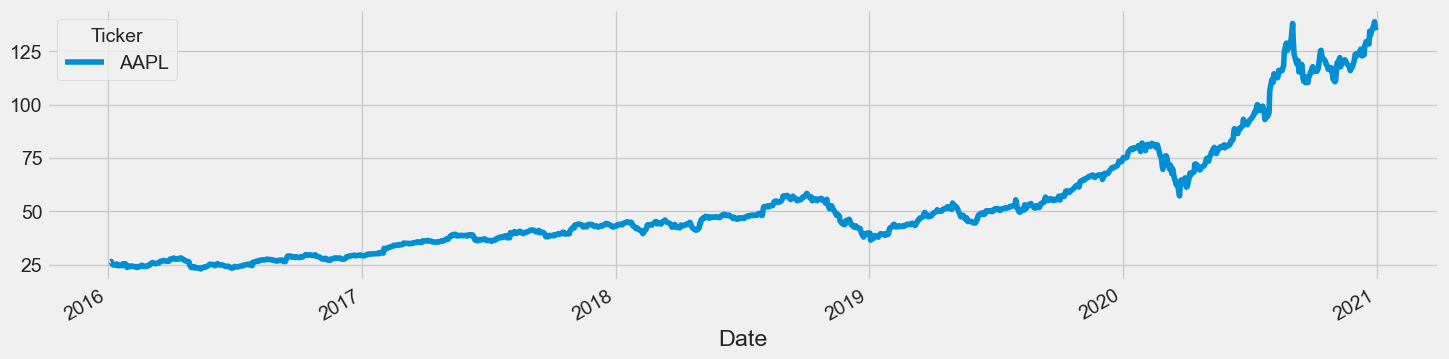

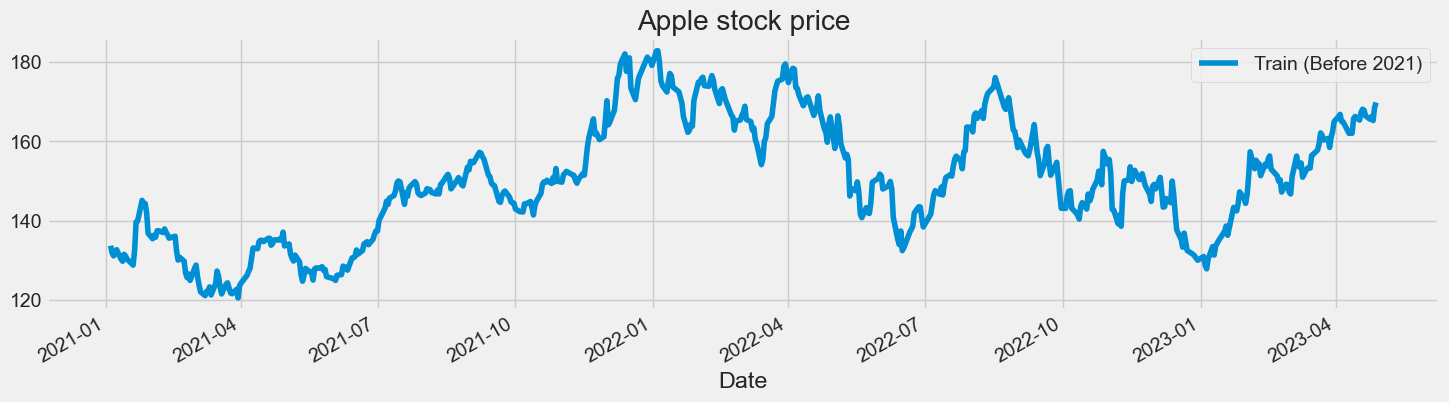

In [139]:
train_test_plot(dataset, tstart, tend)

### Creating train and test datasets

In [140]:
def train_test_split(dataset, tstart, tend, columns = ['High']):
    train = dataset.loc[f"{tstart}":f"{tend}", columns].values
    test = dataset.loc[f"{tend+1}":, columns].values
    return train, test

In [141]:
training_set, test_set = train_test_split(dataset, tstart, tend)

### Scaling dataset values

In [142]:
sc = MinMaxScaler(feature_range=(0, 1))
training_set = training_set.reshape(-1, 1)
training_set_scaled = sc.fit_transform(training_set)

### Creating overlapping window batches

In [143]:
n_steps = 1
features = 1

In [144]:
def split_sequence(sequence, n_steps):
    X, y = list(), list()
    for i in range(len(sequence)):
        end_ix = i + n_steps
        if end_ix > len(sequence) - 1:
            break
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [145]:
X_train, y_train = split_sequence(training_set_scaled, n_steps)

In [146]:
# Reshaping X_train for model
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], features)

### Evaluation

In [147]:
def plot_predictions(test, predicted, title):
    plt.plot(test, color="gray", label="Real")
    plt.plot(predicted, color="red", label="Predicted")
    plt.title(f'{title}')
    plt.xlabel("Time")
    plt.ylabel(f'{title}')
    plt.legend()
    plt.show()

In [148]:
def return_rmse(test, predicted):
    rmse = np.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {:.2f}.".format(rmse))

### Vanilla RNN

In [149]:
def plot_loss(history):
    plt.figure(figsize = (15,10))
    plt.plot(history.history['loss'], label='loss')
    plt.legend(loc='best')
    plt.show()

In [150]:
model_rnn = Sequential()
model_rnn.add(SimpleRNN(units=125, input_shape=(n_steps, features)))
model_rnn.add(Dense(units=1))

In [151]:
# Compiling the model
model_rnn.compile(optimizer="RMSprop", loss="mse")

In [152]:
history = model_rnn.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

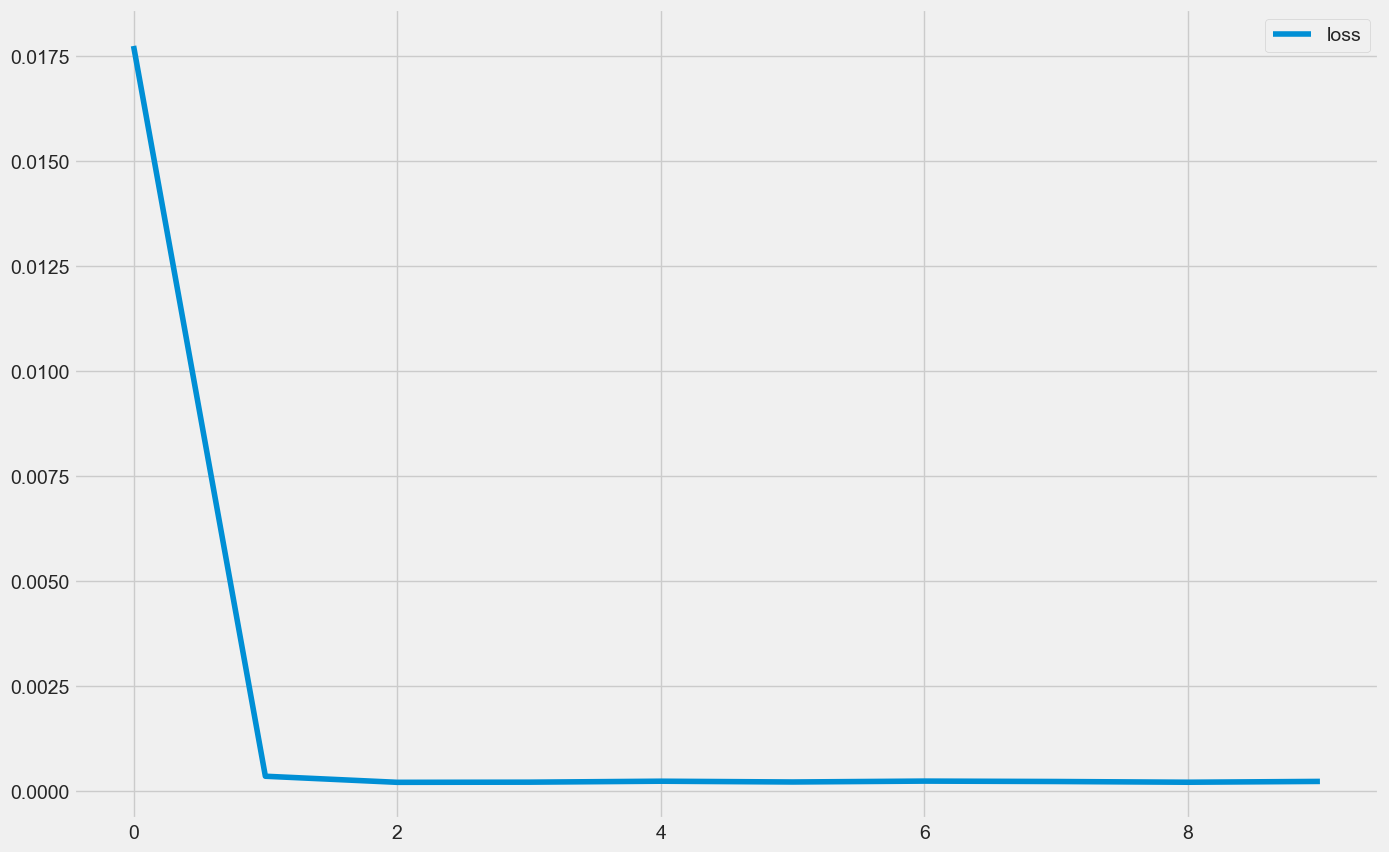

In [153]:
plot_loss(history)

## **Time Series Prediction**

In [154]:
# Scaling
inputs = sc.transform(test_set.reshape(-1, 1))

In [155]:
# Split into samples
X_test, y_test = split_sequence(inputs, n_steps)
# reshape
X_test = X_test.reshape(-1, n_steps, features)

In [156]:
# Prediction
predicted_stock_price = model_rnn.predict(X_test)
# Inverse transform the values
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

19/19 [==============================] - 0s 1ms/step


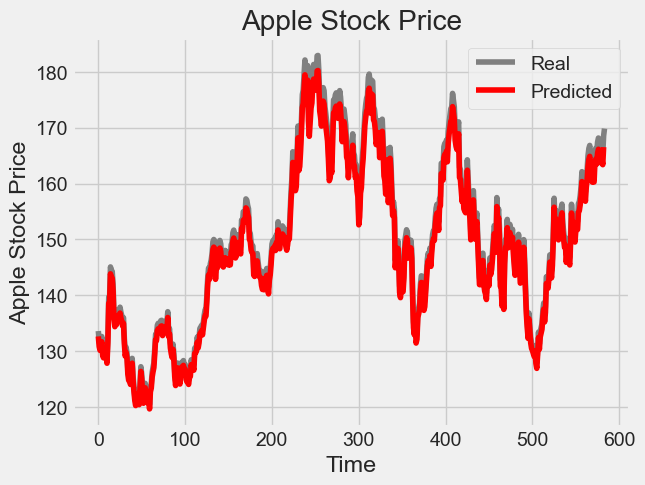

In [157]:
plot_predictions(test_set, predicted_stock_price, "Apple Stock Price")

### Sequence Generation

In [158]:
steps_in_future = 25

In [159]:
def sequence_generation(dataset: pd.DataFrame, sc: MinMaxScaler, model:Sequential, steps_future: int):
    high_dataset = dataset.iloc[len(dataset) - len(test_set) - n_steps:]["High"]
    high_dataset = sc.transform(high_dataset.values.reshape(-1, 1))
    inputs = high_dataset[:n_steps]

    for _ in range(steps_future):
        curr_pred = model.predict(inputs[-n_steps:].reshape(-1, n_steps, features), verbose=0)
        inputs = np.append(inputs, curr_pred, axis=0)

    return sc.inverse_transform(inputs[n_steps:])

In [160]:
results = sequence_generation(dataset, sc, model_rnn, steps_in_future)

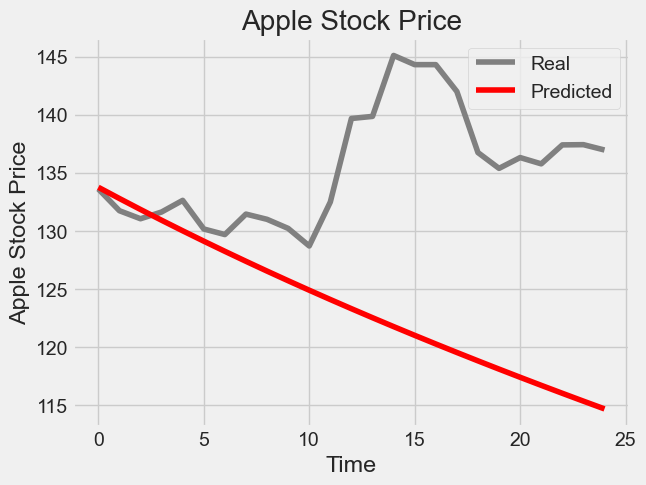

In [161]:
plot_predictions(test_set[:steps_in_future], results, "Apple Stock Price")

## **LSTM**

In [162]:
model_lstm = Sequential()
model_lstm.add(LSTM(units=125, input_shape=(n_steps, features)))
model_lstm.add(Dense(units=1))

In [163]:
# Compiling the model
model_lstm.compile(optimizer="RMSprop", loss="mse")

In [164]:
history = model_lstm.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

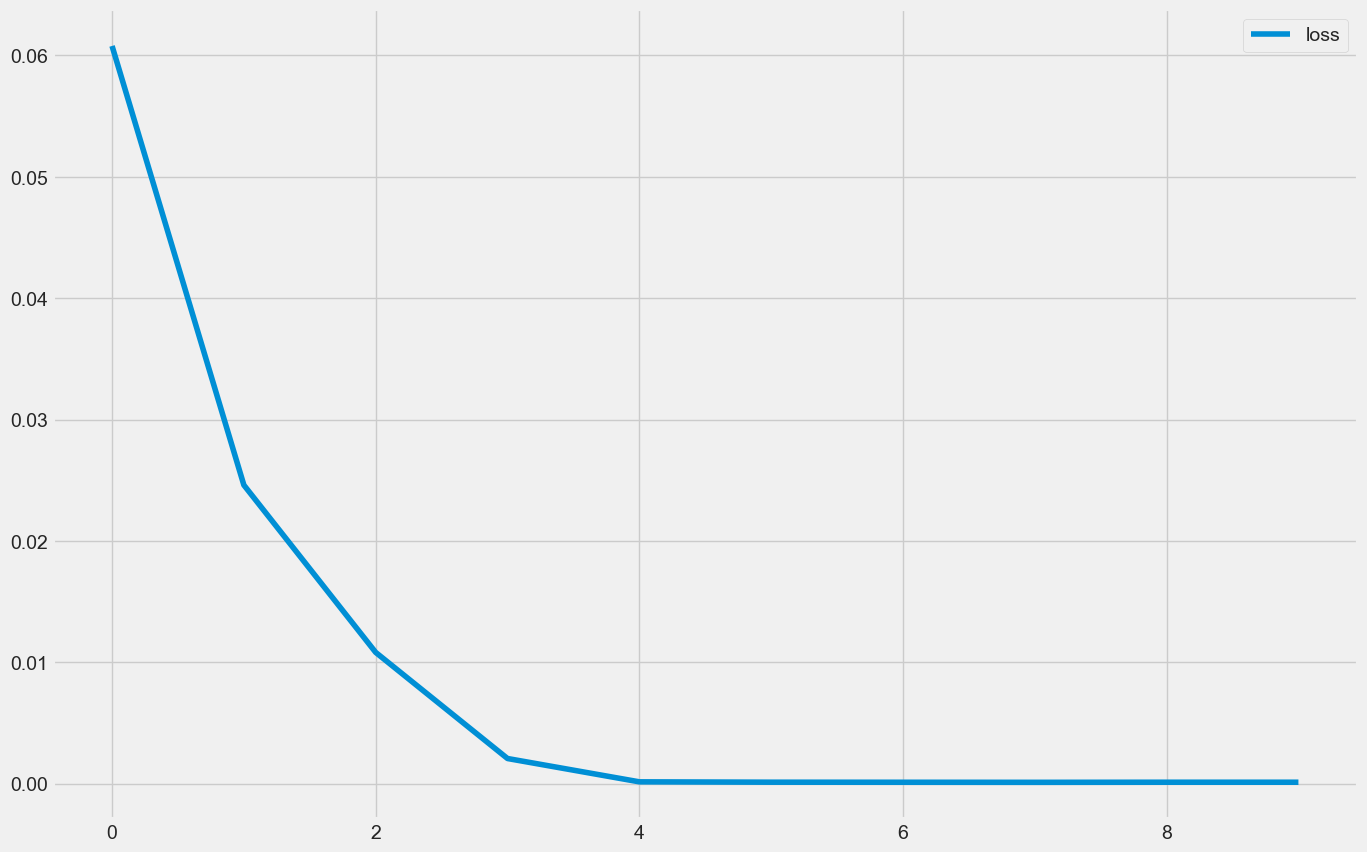

In [165]:
plot_loss(history)

In [166]:
#prediction
predicted_stock_price = model_lstm.predict(X_test)
#inverse transform the values
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

19/19 [==============================] - 0s 1ms/step


### Time Series Prediction: LSTM

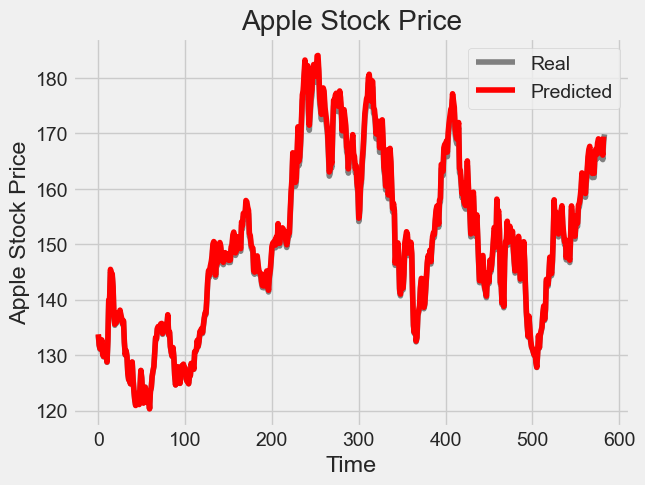

In [167]:
plot_predictions(test_set, predicted_stock_price, "Apple Stock Price")

### Sequence Generation: LSTM

In [168]:
results = sequence_generation(dataset, sc, model_lstm, steps_in_future)

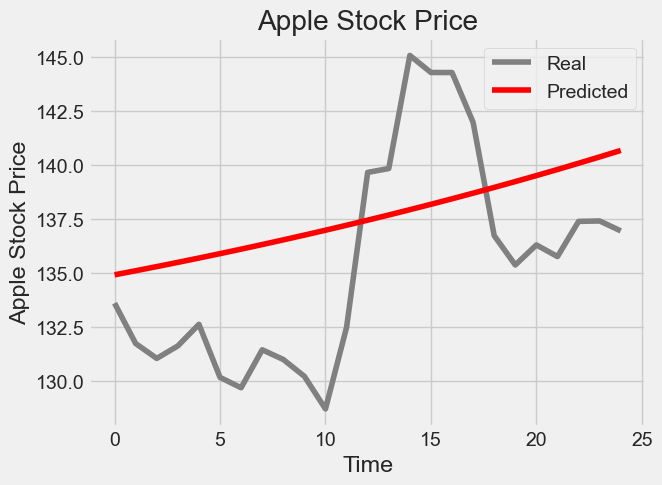

In [169]:
plot_predictions(test_set[:steps_in_future], results, "Apple Stock Price")

## Multivariate Input

In [170]:
mv_features = 6

In [171]:
multi_variate_df = dataset.copy()

In [172]:
multi_variate_df

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2012-01-03,12.359184,14.686786,14.732143,14.607143,14.621429,302220800
2012-01-04,12.425599,14.765714,14.810000,14.617143,14.642857,260022000
2012-01-05,12.563553,14.929643,14.948214,14.738214,14.819643,271269600
2012-01-06,12.694886,15.085714,15.098214,14.972143,14.991786,318292800
2012-01-09,12.674752,15.061786,15.276786,15.048214,15.196429,394024400
...,...,...,...,...,...,...
2023-04-24,163.465012,165.330002,165.600006,163.889999,165.000000,41949600
2023-04-25,161.922577,163.770004,166.309998,163.729996,165.190002,48714100


In [173]:
# grab only the AAPL columns (drops the top level)
multi_variate_df = multi_variate_df.xs('AAPL', axis=1, level='Ticker').copy()

dataset           = dataset.xs('AAPL',           axis=1, level='Ticker').copy()

### Creating Technical Indicators

In [174]:
multi_variate_df['RSI'] = ta.rsi(multi_variate_df.Close, length=15)
multi_variate_df['EMAF'] = ta.ema(multi_variate_df.Close, length=20)
multi_variate_df['EMAM'] = ta.ema(multi_variate_df.Close, length=100)
multi_variate_df['EMAS'] = ta.ema(multi_variate_df.Close, length=150)

### Creating Labels

Labels are created by calculating the difference in closing price of share.

In [175]:
multi_variate_df['Target'] = (multi_variate_df['Adj Close'] - dataset['Open']).shift(-1)

multi_variate_df.dropna(inplace=True)
multi_variate_df.drop(['Volume', 'Close'], axis=1, inplace=True)

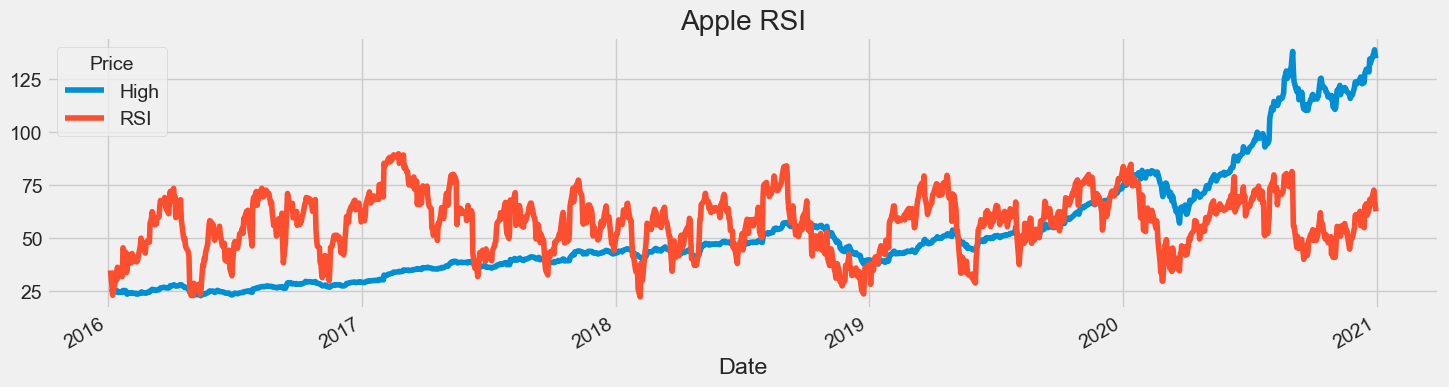

In [176]:
multi_variate_df.loc[f"{tstart}":f"{tend}", ['High', 'RSI']].plot(figsize=(16, 4), legend=True)
plt.title("Apple RSI")
plt.show()

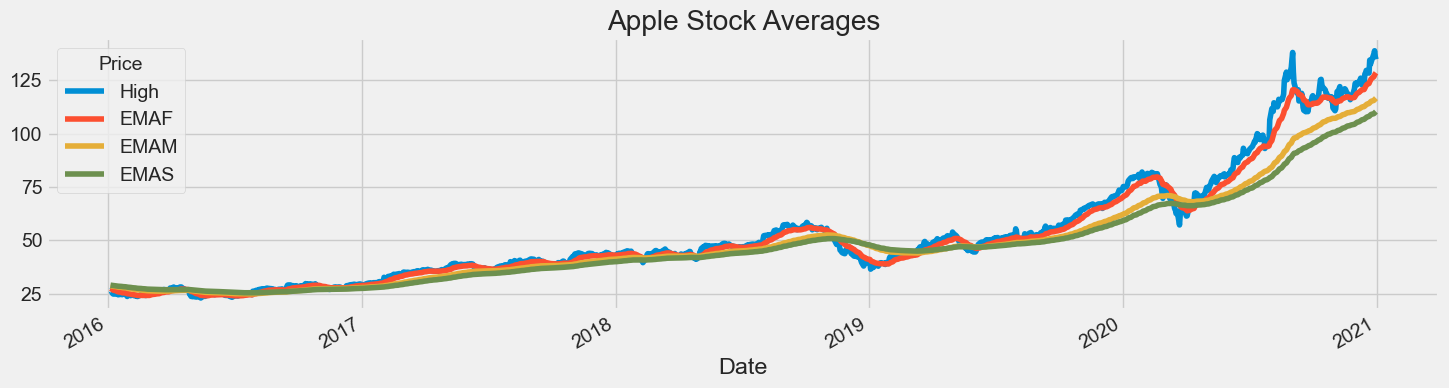

In [177]:
multi_variate_df.loc[f"{tstart}":f"{tend}", ['High', 'EMAF', 'EMAM', 'EMAS']].plot(figsize=(16, 4), legend=True)
plt.title("Apple Stock Averages")
plt.show()

In [178]:
feat_columns = ['Open', 'High', 'RSI', 'EMAF', 'EMAM', 'EMAS']
label_col = ['Target']

### Splitting train and test data

In [179]:
mv_training_set, mv_test_set = train_test_split(multi_variate_df, tstart, tend, feat_columns + label_col)

In [180]:
mv_training_set.shape

(1259, 7)

In [103]:
X_train = mv_training_set[:, :-1]
y_train = mv_training_set[:, -1]

X_test = mv_test_set[:, :-1]
y_test = mv_test_set[:, -1]

In [181]:
X_train.shape

(1258, 1, 1)

### Scaling Data

In [184]:
# 1) Un–reshape X_train / X_test into 2D (samples, features)
n_train, timesteps, n_feat = X_train.shape
n_test  = X_test.shape[0]

# timesteps is 1 in your case, so this is equivalent to
X_train_2d = X_train.reshape(n_train, n_feat)
X_test_2d  = X_test .reshape(n_test,  n_feat)

mv_sc = MinMaxScaler(feature_range=(0, 1))
# 2) Fit & transform on the 2D arrays
X_train_scaled_2d = mv_sc.fit_transform(X_train_2d)
X_test_scaled_2d  = mv_sc.transform(   X_test_2d)

# 3) Reshape back into LSTM 3D shape (samples, timesteps, features)
X_train = X_train_scaled_2d.reshape(n_train, timesteps, n_feat)
X_test  = X_test_scaled_2d .reshape(n_test,  timesteps, n_feat)

print("Final X_train shape:", X_train.shape)  # should be (1258, 1, n_feat)
print("Final X_test  shape:", X_test.shape)

Final X_train shape: (1258, 1, 1)
Final X_test  shape: (583, 1, 1)


### Model

In [187]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

model_mv = Sequential([
    LSTM(50, input_shape=(1, n_feat)),  # note: 1 timestep, n_feat features
    Dense(1)
])
model_mv.compile(optimizer='adam', loss='mse')


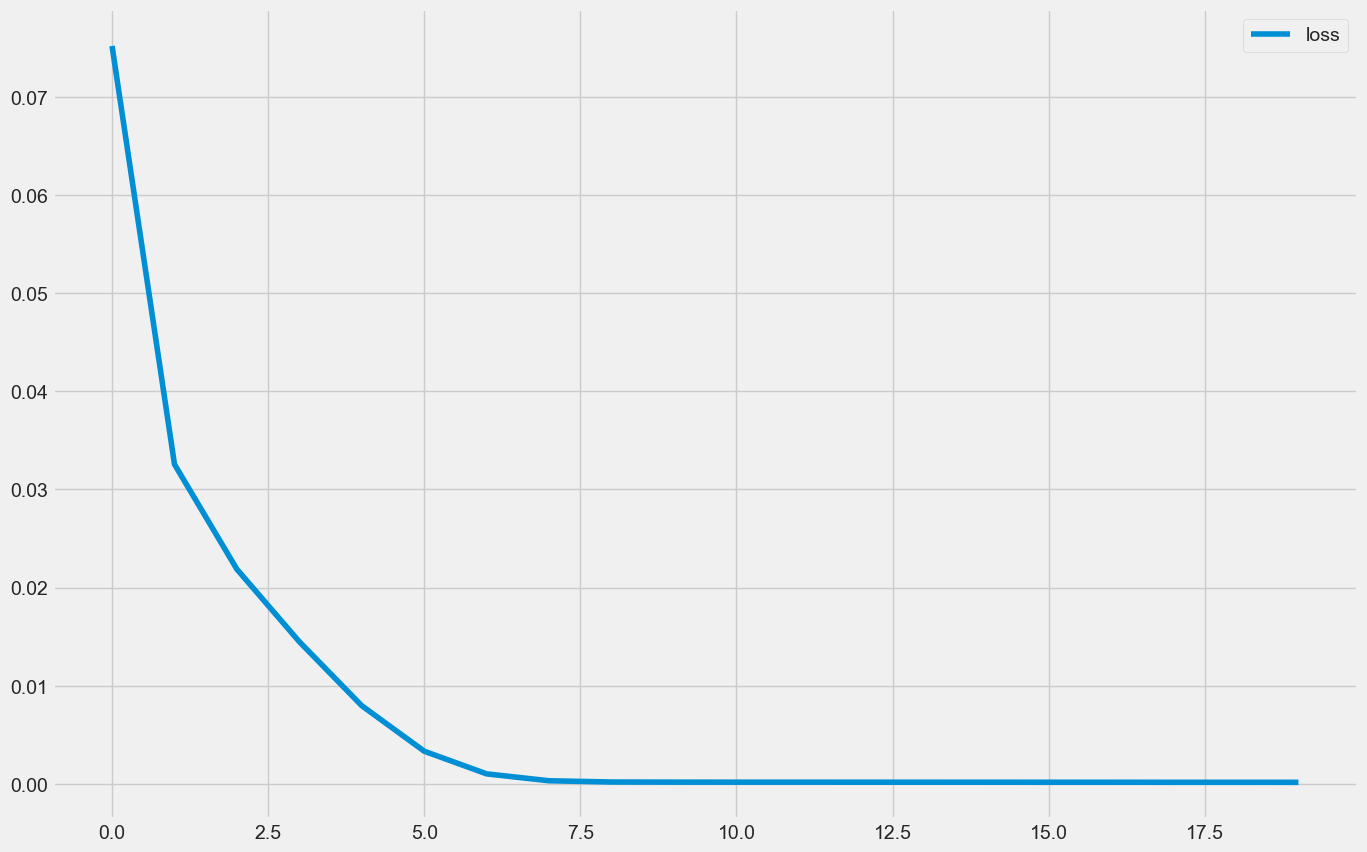

In [188]:
history = model_mv.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)
plot_loss(history)

### Results

19/19 [==============================] - 0s 1ms/step


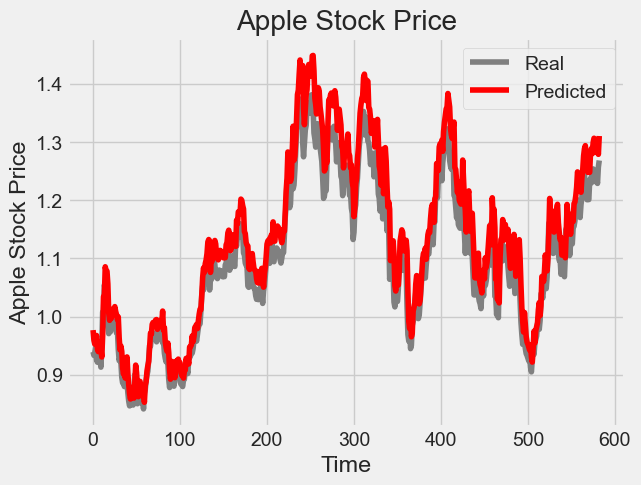

In [189]:
predictions = model_mv.predict(X_test)
plot_predictions(y_test, predictions, "Apple Stock Price")